In [13]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [14]:
DATA = r"D:\Newborn Heart Risk Prediction\newborn_heart_risk_dataset.csv"
MODEL = "newborn_risk_model.pkl"

In [15]:
FEATURES = [
    "Sex",
    "Gestational_Age_weeks",
    "Birth_Weight_kg",
    "Heart_Rate_bpm",
    "Respiratory_Rate_bpm",
    "Oxygen_Saturation_percent",
    "Feeding_Frequency_per_day",
    "Urine_Output_Count",
    "Jaundice_Level_mg_dL",
    "Temperature_C",
    "Apgar_Score",
    "Oxygen_Given",
    "Resuscitation_Required"
]

df = pd.read_csv(DATA)

X = df[FEATURES]
y = df["Risk_Level"]

categorical = ["Sex"]
numeric = [c for c in FEATURES if c not in categorical]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", "passthrough", numeric)
])

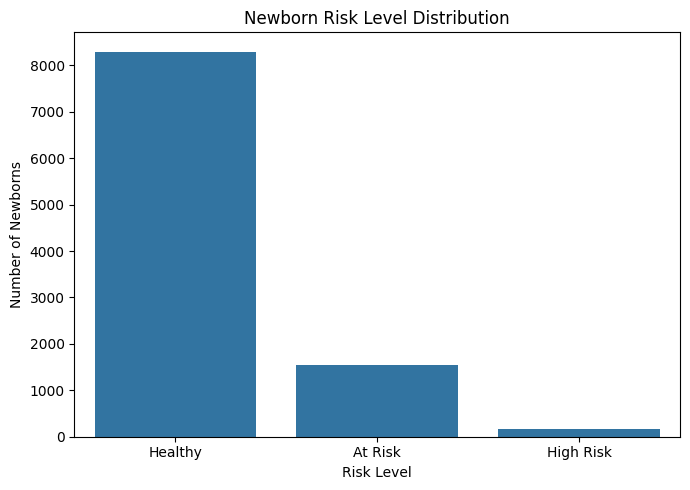

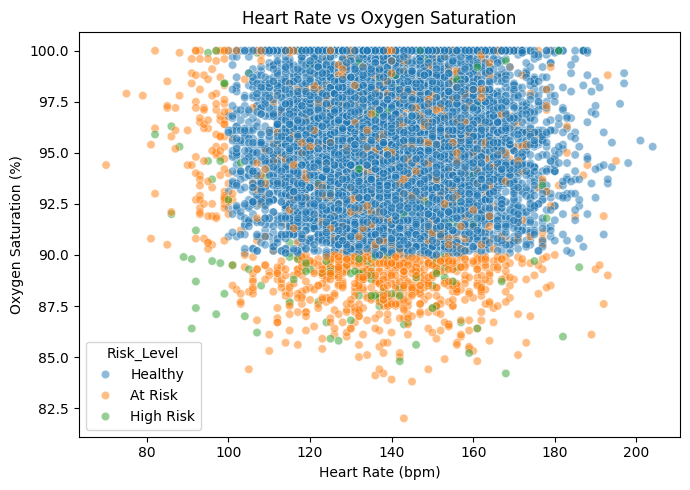

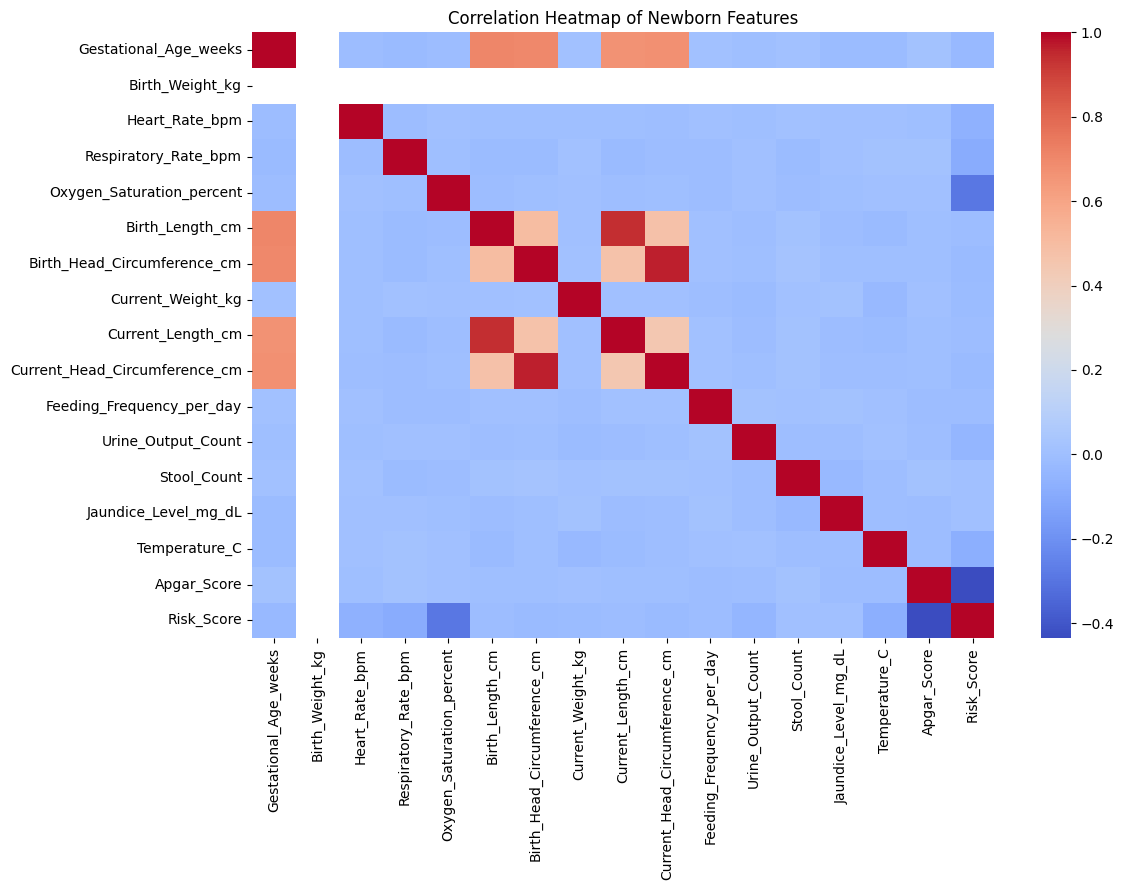

In [16]:
# 1.RISK LEVEL DISTRIBUTION
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Risk_Level",
    order=["Healthy", "At Risk", "High Risk"]
)

plt.title("Newborn Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Newborns")
plt.tight_layout()
plt.show()

# 2. HEART RATE vs OXYGEN SATURATION
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Heart_Rate_bpm",
    y="Oxygen_Saturation_percent",
    hue="Risk_Level",
    alpha=0.5
)

plt.title("Heart Rate vs Oxygen Saturation")
plt.xlabel("Heart Rate (bpm)")
plt.ylabel("Oxygen Saturation (%)")
plt.tight_layout()
plt.show()

# 3. CORRELATION HEATMAP
features = [
    "Gestational_Age_weeks",
    "Birth_Weight_kg",
    "Heart_Rate_bpm",
    "Respiratory_Rate_bpm",
    "Oxygen_Saturation_percent",
    "Birth_Length_cm",
    "Birth_Head_Circumference_cm",
    "Current_Weight_kg",
    "Current_Length_cm",
    "Current_Head_Circumference_cm",
    "Feeding_Frequency_per_day",
    "Urine_Output_Count",
    "Stool_Count",
    "Jaundice_Level_mg_dL",
    "Temperature_C",
    "Apgar_Score",
    "Risk_Score"
]
plt.figure(figsize=(12, 9))

sns.heatmap(
    df[features].corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Newborn Features")
plt.tight_layout()
plt.show()

In [17]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

print("Model Accuracy:", round(accuracy_score(y_test, pred) * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

joblib.dump(pipeline, MODEL)
print("\nSaved model:", MODEL)

Model Accuracy: 98.2 %

Classification Report:

              precision    recall  f1-score   support

     At Risk       0.97      0.92      0.94       309
     Healthy       0.98      1.00      0.99      1659
   High Risk       1.00      0.69      0.81        32

    accuracy                           0.98      2000
   macro avg       0.98      0.87      0.92      2000
weighted avg       0.98      0.98      0.98      2000


Saved model: newborn_risk_model.pkl
